[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nmickevicius/MCW_BIOP_03-238_MRI/blob/main/11_12_selective_excitation/selective_excitation.ipynb)

In [11]:
%matplotlib inline
import numpy as np
from ipywidgets import interact, FloatSlider, Checkbox
from IPython.display import HTML, display
import matplotlib.pyplot as plt

# Gyromagnetic constants
gamma_hz_per_t  = 42.577e6                 # Hz/T
gamma_rad_per_t = 2*np.pi*gamma_hz_per_t   # rad/s/T

def sinc_rf_pulse(t, T, BW_hz):
    """Basebanded sinc RF envelope centered at T/2 with bandwidth BW (Hz)."""
    x = BW_hz*(t - T/2)
    return np.sinc(x)

def scale_for_flip_angle(b1, t, flip_angle_deg):
    """
    Scale RF to achieve the target flip angle (deg) under on-resonance condition
    """
    alpha = np.deg2rad(flip_angle_deg)
    area  = np.trapz(b1, t)
    if np.isclose(area, 0.0):
        return 0.0
    return alpha / (gamma_rad_per_t * area)

def slice_select_gradient(BW_hz, slice_thickness_mm):
    """
    Constant slice-select gradient during RF
    """
    dz_m = max(1e-6, slice_thickness_mm * 1e-3)  # avoid divide-by-zero
    return BW_hz / (gamma_hz_per_t * dz_m)  # T/m

def rotation_matrix_x(alpha):
    R = np.zeros((3,3))
    R[0,0] = 1.0 
    R[1,1] = np.cos(alpha) 
    R[1,2] = -np.sin(alpha) 
    R[2,1] = np.sin(alpha) 
    R[2,2] = np.cos(alpha) 
    return R

def rotation_matrix_y(alpha):
    R = np.zeros((3,3))
    R[0,0] = np.cos(alpha)
    R[0,2] = np.sin(alpha)
    R[1,1] = 1.0 
    R[2,0] = -np.sin(alpha) 
    R[2,2] = np.cos(alpha) 
    return R

def bloch_sim_rf(b1_t, t, G_t, z_axis_m):
    
    M_final = np.zeros((z_axis_m.size, 3))
    # Time steps
    dt = np.diff(t)

    M = np.zeros((3,z_axis_m.size))
    M[2,:] = 1.0 
    rephase = 0.0
    for k in range(len(dt)):
        alpha_x = gamma_rad_per_t * np.real(b1_t[k]) * dt[k]
        alpha_y = gamma_rad_per_t * np.imag(b1_t[k]) * dt[k]
        Rx = rotation_matrix_x(alpha_x) 
        Ry = rotation_matrix_y(alpha_y) 
        M = (Ry @ Rx) @ M 
        z_phase = gamma_rad_per_t * G_t[k] * z_axis_m * dt[k]
        mxy = (M[0,:] + 1j*M[1,:]) * np.exp(1j * z_phase)
        M[0,:] = np.real(mxy) 
        M[1,:] = np.imag(mxy)
        if k >= len(dt)//2:
            rephase += z_phase 
    mxy = (M[0,:] + 1j*M[1,:]) * np.exp(-1j * rephase) # slice rewinder 
    M[0,:] = np.real(mxy) 
    M[1,:] = np.imag(mxy)
    return M.T


def plot_all(slice_thickness_mm=5.0, offiso_mm=0.0, duration_ms=4.0, bandwidth_hz=2000.0,
             flip_angle_deg=90.0, window_rf=False, z_span_factor=3.0):
    # --- Time grid ---
    T = max(1e-3, duration_ms * 1e-3)                     # s
    n = int(np.clip(T / 5e-6, 1200, 6000))                # balance speed/accuracy
    t = np.linspace(0, T, n)

    # --- RF envelope (unit sinc) ---
    b1_env = sinc_rf_pulse(t, T, bandwidth_hz)

    # Optional Hamming window to reduce sidelobes
    if window_rf:
        w = 0.54 - 0.46*np.cos(2*np.pi*np.linspace(0, 1, n))
        b1_env = b1_env * w

    # --- Scale RF to requested flip angle ---
    scale = scale_for_flip_angle(b1_env, t, flip_angle_deg)
    b1_t  = scale * b1_env  # Tesla

    # --- Slice-select gradient (constant during RF) ---
    G = slice_select_gradient(bandwidth_hz, slice_thickness_mm)  # T/m
    G_t = np.ones_like(t) * G

    # --- add linear phase over time to shift slice --- 
    ph = np.exp(1j * gamma_rad_per_t * G * (offiso_mm * 1e-3) * t ) 
    b1_t = b1_t * ph

    # --- Spatial grid (± z_span_factor × slice thickness) ---
    z_span_mm = max(1.0, z_span_factor * slice_thickness_mm)
    z_mm = np.linspace(-z_span_mm, z_span_mm, 321)
    z_m  = z_mm * 1e-3

    # --- Bloch sim through RF pulse ---
    M_end = bloch_sim_rf(b1_t, t, G_t, z_m)

    # --- Ideal slice rephaser to remove post-isocenter phase from G ---
    # M_end = apply_slice_rephaser(M_end, t, G_t, z_m, T)

    # --- Extract transverse components after rephaser ---
    Mx, My, Mz = M_end[:, 0], M_end[:, 1], M_end[:, 2]
    Mxy = Mx + 1j*My
    mag = np.abs(Mxy)
    ph_deg = np.angle(Mxy, deg=True)

    # --- Single figure with three stacked subplots ---
    fig = plt.figure(figsize=(7.5, 8.5))

    # 1) RF pulse
    ax1 = fig.add_subplot(3,1,1)
    ax1.plot(t*1e3, np.real(b1_t))
    ax1.plot(t*1e3, np.imag(b1_t))
    ax1.plot(t*1e3, np.abs(b1_t))
    ax1.set_title("RF Sinc Pulse")
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("B1 (T)")
    ax1.grid(True)

    # 2) Slice-select gradient
    ax2 = fig.add_subplot(3,1,2)
    ax2.plot(t*1e3, G_t)
    ax2.set_title("Slice-Select Gradient During RF")
    ax2.set_xlabel("Time (ms)")
    ax2.set_ylabel("G (T/m)")
    ax2.grid(True)

    # 3) Slice profile: |Mxy| and phase (yy plot)
    ax3 = fig.add_subplot(3,1,3)
    ax3.plot(z_mm, mag, label="|Mxy|")
    ax3.set_xlabel("Position z (mm)")
    ax3.set_ylabel("|Mxy| (a.u.)")
    ax3.grid(True)
    ax3b = ax3.twinx()
    ax3b.plot(z_mm, ph_deg, label="Phase", color='orange')
    ax3b.set_ylabel("Phase (deg)")
    fig.tight_layout()
    plt.show()

    # Quick readout
    tbw = bandwidth_hz * T
    display(HTML(f"""
    <div style='font-family:sans-serif;line-height:1.5;margin-top:8px'>
      <b>Parameters</b><br>
      Slice thickness: {slice_thickness_mm:.2f} mm<br>
      Duration: {duration_ms:.3f} ms<br>
      Bandwidth: {bandwidth_hz:.1f} Hz<br>
      Flip angle: {flip_angle_deg:.1f}&deg;<br>
      Required G: {G:.5f} T/m<br>
      Approx. TBW: {tbw:.2f}<br>
      Note: Bloch sim without relaxation; ideal post-isocenter slice rephaser applied.
    </div>
    """))

# Widgets / Controls
interact(
    plot_all,
    slice_thickness_mm=FloatSlider(value=5.0, min=0.5, max=20.0, step=0.1, description="Slice (mm)"),
    offiso_mm=FloatSlider(value=0.0, min=-5.0, max=5.0, step=0.1, description="Slice Shift (mm)"),
    duration_ms=FloatSlider(value=4.0, min=0.5, max=20.0, step=0.1, description="Duration (ms)"),
    bandwidth_hz=FloatSlider(value=2000.0, min=200.0, max=10000.0, step=50.0, description="BW (Hz)"),
    flip_angle_deg=FloatSlider(value=10.0, min=1.0, max=180.0, step=1.0, description="Flip (deg)"),
    window_rf=Checkbox(value=False, description="Hamming window"),
    z_span_factor=FloatSlider(value=3.0, min=1.0, max=6.0, step=0.5, description="z-span × thickness")
);


interactive(children=(FloatSlider(value=5.0, description='Slice (mm)', max=20.0, min=0.5), FloatSlider(value=0…

# Simultaneous Multi-Slice Excitation

In [12]:
%matplotlib inline
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox
from IPython.display import HTML, display
import matplotlib.pyplot as plt
from copy import deepcopy 

# Gyromagnetic constants
gamma_hz_per_t  = 42.577e6                 # Hz/T
gamma_rad_per_t = 2*np.pi*gamma_hz_per_t   # rad/s/T

def sinc_rf_pulse(t, T, BW_hz):
    """Basebanded sinc RF envelope centered at T/2 with bandwidth BW (Hz)."""
    x = BW_hz*(t - T/2)
    return np.sinc(x)

def scale_for_flip_angle(b1, t, flip_angle_deg):
    """
    Scale RF to achieve the target flip angle (deg) under on-resonance condition
    """
    alpha = np.deg2rad(flip_angle_deg)
    area  = np.trapz(b1, t)
    if np.isclose(area, 0.0):
        return 0.0
    return alpha / (gamma_rad_per_t * area)

def slice_select_gradient(BW_hz, slice_thickness_mm):
    """
    Constant slice-select gradient during RF
    """
    dz_m = max(1e-6, slice_thickness_mm * 1e-3)  # avoid divide-by-zero
    return BW_hz / (gamma_hz_per_t * dz_m)  # T/m

def rotation_matrix_x(alpha):
    R = np.zeros((3,3))
    R[0,0] = 1.0 
    R[1,1] = np.cos(alpha) 
    R[1,2] = -np.sin(alpha) 
    R[2,1] = np.sin(alpha) 
    R[2,2] = np.cos(alpha) 
    return R

def rotation_matrix_y(alpha):
    R = np.zeros((3,3))
    R[0,0] = np.cos(alpha)
    R[0,2] = np.sin(alpha)
    R[1,1] = 1.0 
    R[2,0] = -np.sin(alpha) 
    R[2,2] = np.cos(alpha) 
    return R

def bloch_sim_rf(b1_t, t, G_t, z_axis_m):
    
    M_final = np.zeros((z_axis_m.size, 3))
    # Time steps
    dt = np.diff(t)

    M = np.zeros((3,z_axis_m.size))
    M[2,:] = 1.0 
    rephase = 0.0
    for k in range(len(dt)):
        alpha_x = gamma_rad_per_t * np.real(b1_t[k]) * dt[k]
        alpha_y = gamma_rad_per_t * np.imag(b1_t[k]) * dt[k]
        Rx = rotation_matrix_x(alpha_x) 
        Ry = rotation_matrix_y(alpha_y) 
        M = (Ry @ Rx) @ M 
        z_phase = gamma_rad_per_t * G_t[k] * z_axis_m * dt[k]
        mxy = (M[0,:] + 1j*M[1,:]) * np.exp(1j * z_phase)
        M[0,:] = np.real(mxy) 
        M[1,:] = np.imag(mxy)
        if k >= len(dt)//2:
            rephase += z_phase 
    mxy = (M[0,:] + 1j*M[1,:]) * np.exp(-1j * rephase) # slice rewinder 
    M[0,:] = np.real(mxy) 
    M[1,:] = np.imag(mxy)
    return M.T


def plot_all(num_slices=3, slice_thickness_mm=5.0, slice_spacing=10.0, duration_ms=4.0, bandwidth_hz=2000.0,
             flip_angle_deg=90.0, window_rf=False):
    # --- Time grid ---
    T = max(1e-3, duration_ms * 1e-3)                     # s
    n = int(np.clip(T / 5e-6, 1200, 6000))                # balance speed/accuracy
    t = np.linspace(0, T, n)

    # --- RF envelope (unit sinc) ---
    b1_env = sinc_rf_pulse(t, T, bandwidth_hz)

    # Optional Hamming window to reduce sidelobes
    if window_rf:
        w = 0.54 - 0.46*np.cos(2*np.pi*np.linspace(0, 1, n))
        b1_env = b1_env * w

    # --- Scale RF to requested flip angle ---
    scale = scale_for_flip_angle(b1_env, t, flip_angle_deg)
    b1_t  = scale * b1_env  # Tesla

    # --- Slice-select gradient (constant during RF) ---
    G = slice_select_gradient(bandwidth_hz, slice_thickness_mm)  # T/m
    G_t = np.ones_like(t) * G

    # --- add linear phase over time to shift slice --- 
    b1_t_sb = deepcopy(b1_t)
    b1_t = np.zeros_like(b1_t_sb)
    for n in range(num_slices): 
        ph = np.exp(1j * gamma_rad_per_t * G * (n * slice_spacing * 1e-3) * t ) 
        b1_t = b1_t + b1_t_sb * ph

    # --- Spatial grid (± z_span_factor × slice thickness) ---
    # z_span_mm = max(1.0, z_span_factor * slice_thickness_mm)
    # z_mm = np.linspace(-z_span_mm, z_span_mm, 321)
    z_mm = np.linspace(-1.5*slice_thickness_mm, (num_slices-1)*slice_spacing+1.5*slice_thickness_mm, 321)
    z_m  = z_mm * 1e-3

    # --- Bloch sim through RF pulse ---
    M_end = bloch_sim_rf(b1_t, t, G_t, z_m)

    # --- Extract transverse components after rephaser ---
    Mx, My, Mz = M_end[:, 0], M_end[:, 1], M_end[:, 2]
    Mxy = Mx + 1j*My
    mag = np.abs(Mxy)
    ph_deg = np.angle(Mxy, deg=True)

    # --- Single figure with three stacked subplots ---
    fig = plt.figure(figsize=(7.5, 8.5))

    # 1) RF pulse
    ax1 = fig.add_subplot(2,1,1)
    ax1.plot(t*1e3, np.real(b1_t))
    ax1.plot(t*1e3, np.imag(b1_t))
    ax1.plot(t*1e3, np.abs(b1_t))
    ax1.set_title("RF Sinc Pulse")
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("B1 (T)")
    ax1.grid(True)

    # 3) Slice profile: |Mxy| and phase (yy plot)
    ax3 = fig.add_subplot(2,1,2)
    ax3.plot(z_mm, mag, label="|Mxy|")
    ax3.set_xlabel("Position z (mm)")
    ax3.set_ylabel("|Mxy| (a.u.)")
    ax3.grid(True)
    ax3b = ax3.twinx()
    ax3b.plot(z_mm, ph_deg, label="Phase", color='orange')
    ax3b.set_ylabel("Phase (deg)")
    fig.tight_layout()
    plt.show()

    # Quick readout
    tbw = bandwidth_hz * T
    display(HTML(f"""
    <div style='font-family:sans-serif;line-height:1.5;margin-top:8px'>
      <b>Parameters</b><br>
      Slice thickness: {slice_thickness_mm:.2f} mm<br>
      Duration: {duration_ms:.3f} ms<br>
      Bandwidth: {bandwidth_hz:.1f} Hz<br>
      Flip angle: {flip_angle_deg:.1f}&deg;<br>
      Required G: {G:.5f} T/m<br>
      Approx. TBW: {tbw:.2f}<br>
      Note: Bloch sim without relaxation; ideal post-isocenter slice rephaser applied.
    </div>
    """))

# Widgets / Controls
interact(
    plot_all,
    num_slices=IntSlider(value=3, min=1, max=5, step=1, description="Number of Slices"),
    slice_thickness_mm=FloatSlider(value=5.0, min=0.5, max=20.0, step=0.1, description="Slice (mm)"),
    slice_spacing=FloatSlider(value=10.0, min=10.0, max=20.0, step=0.1, description="Slice Spacing (mm)"),
    duration_ms=FloatSlider(value=4.0, min=0.5, max=20.0, step=0.1, description="Duration (ms)"),
    bandwidth_hz=FloatSlider(value=2000.0, min=200.0, max=10000.0, step=50.0, description="BW (Hz)"),
    flip_angle_deg=FloatSlider(value=10.0, min=1.0, max=180.0, step=1.0, description="Flip (deg)"),
    window_rf=Checkbox(value=False, description="Hamming window"),
);


interactive(children=(IntSlider(value=3, description='Number of Slices', max=5, min=1), FloatSlider(value=5.0,…

In [13]:
%matplotlib inline
import numpy as np
from ipywidgets import interact, FloatSlider, Checkbox
from IPython.display import HTML, display
import matplotlib.pyplot as plt

# Gyromagnetic constants
gamma_hz_per_t  = 42.577e6                 # Hz/T
gamma_rad_per_t = 2*np.pi*gamma_hz_per_t   # rad/s/T

def sinc_rf_pulse(t, T, BW_hz):
    """Basebanded sinc RF envelope centered at T/2 with bandwidth BW (Hz)."""
    x = BW_hz*(t - T/2)
    return np.sinc(x)

def scale_for_flip_angle(b1, t, flip_angle_deg):
    """
    Scale RF to achieve the target flip angle (deg) under on-resonance condition
    """
    alpha = np.deg2rad(flip_angle_deg)
    area  = np.trapz(b1, t)
    if np.isclose(area, 0.0):
        return 0.0
    return alpha / (gamma_rad_per_t * area)

def slice_select_gradient(BW_hz, slice_thickness_mm):
    """
    Constant slice-select gradient during RF
    """
    dz_m = max(1e-6, slice_thickness_mm * 1e-3)  # avoid divide-by-zero
    return BW_hz / (gamma_hz_per_t * dz_m)  # T/m

def rotation_matrix_x(alpha):
    R = np.zeros((3,3))
    R[0,0] = 1.0 
    R[1,1] = np.cos(alpha) 
    R[1,2] = -np.sin(alpha) 
    R[2,1] = np.sin(alpha) 
    R[2,2] = np.cos(alpha) 
    return R

def rotation_matrix_y(alpha):
    R = np.zeros((3,3))
    R[0,0] = np.cos(alpha)
    R[0,2] = np.sin(alpha)
    R[1,1] = 1.0 
    R[2,0] = -np.sin(alpha) 
    R[2,2] = np.cos(alpha) 
    return R

def bloch_sim_rf_2d(b1_t, t, Gr_t, Gc_t, r_m, c_m):
    
    # Time steps
    dt = np.diff(t)

    M = np.zeros((3,r_m.size))
    M[2,:] = 1.0 
    rephase_r = 0.0
    rephase_c = 0.0
    for k in range(len(dt)):
        alpha_x = gamma_rad_per_t * np.real(b1_t[k]) * dt[k]
        alpha_y = gamma_rad_per_t * np.imag(b1_t[k]) * dt[k]
        Rx = rotation_matrix_x(alpha_x) 
        Ry = rotation_matrix_y(alpha_y) 
        M = (Ry @ Rx) @ M 
        r_phase = gamma_rad_per_t * Gr_t[k] * r_m * dt[k]
        c_phase = gamma_rad_per_t * Gc_t[k] * c_m * dt[k]
        mxy = (M[0,:] + 1j*M[1,:]) * np.exp(1j * (r_phase + c_phase))
        M[0,:] = np.real(mxy) 
        M[1,:] = np.imag(mxy)
        if k >= len(dt)//2:
            rephase_r += r_phase
            rephase_c += c_phase  
    mxy = (M[0,:] + 1j*M[1,:]) * np.exp(-1j * (rephase_r + rephase_c)) # slice rewinder 
    M[0,:] = np.real(mxy) 
    M[1,:] = np.imag(mxy)
    return M.T


def plot_all(slice_thickness_mm=5.0, angle=0.0, offiso_mm=0.0, duration_ms=4.0, bandwidth_hz=2000.0,
             flip_angle_deg=90.0, window_rf=False, z_span_factor=3.0):
    # --- Time grid ---
    T = max(1e-3, duration_ms * 1e-3)                     # s
    n = int(np.clip(T / 5e-6, 1200, 6000))                # balance speed/accuracy
    t = np.linspace(0, T, n)

    # --- RF envelope (unit sinc) ---
    b1_env = sinc_rf_pulse(t, T, bandwidth_hz)

    # Optional Hamming window to reduce sidelobes
    if window_rf:
        w = 0.54 - 0.46*np.cos(2*np.pi*np.linspace(0, 1, n))
        b1_env = b1_env * w

    # --- Scale RF to requested flip angle ---
    scale = scale_for_flip_angle(b1_env, t, flip_angle_deg)
    b1_t  = scale * b1_env  # Tesla

    # --- Slice-select gradient (constant during RF) ---
    G = slice_select_gradient(bandwidth_hz, slice_thickness_mm)  # T/m
    G_t = np.ones_like(t) * G
    Gr_t = G_t * np.cos(angle * np.pi / 180)
    Gc_t = G_t * np.sin(angle * np.pi / 180)

    # --- add linear phase over time to shift slice --- 
    ph = np.exp(1j * gamma_rad_per_t * G * (offiso_mm * 1e-3) * t ) 
    b1_t = b1_t * ph

    # --- Spatial grid (± z_span_factor × slice thickness) ---
    z_span_mm = max(1.0, z_span_factor * slice_thickness_mm)
    z_mm = np.linspace(-z_span_mm, z_span_mm, 321)
    z_m  = z_mm * 1e-3

    r_m, c_m = np.meshgrid(np.linspace(-0.02, 0.02, 64), np.linspace(-0.02, 0.02, 64), indexing='ij')
    r_m = r_m.flatten()
    c_m = c_m.flatten()

    # --- Bloch sim through RF pulse ---
    M_end = bloch_sim_rf_2d(b1_t, t, Gr_t, Gc_t, r_m, c_m)

    # --- Ideal slice rephaser to remove post-isocenter phase from G ---
    # M_end = apply_slice_rephaser(M_end, t, G_t, z_m, T)

    # --- Extract transverse components after rephaser ---
    Mx, My, Mz = M_end[:, 0], M_end[:, 1], M_end[:, 2]
    Mxy = Mx + 1j*My
    Mxy = Mxy.reshape(64, 64)
    mag = np.abs(Mxy)
    ph_deg = np.angle(Mxy, deg=True)

    # --- Single figure with three stacked subplots ---
    fig = plt.figure(figsize=(7.5, 8.5))

    # 2) Slice-select gradient
    ax2 = fig.add_subplot(1,1,1)
    ax2.imshow(np.abs(Mxy))
    ax2.set_title("Transverse magnetization")
    ax2.set_xlabel("x")
    ax2.set_ylabel("z")
    plt.show()
    

    # Quick readout
    tbw = bandwidth_hz * T
    display(HTML(f"""
    <div style='font-family:sans-serif;line-height:1.5;margin-top:8px'>
      <b>Parameters</b><br>
      Slice thickness: {slice_thickness_mm:.2f} mm<br>
      Duration: {duration_ms:.3f} ms<br>
      Bandwidth: {bandwidth_hz:.1f} Hz<br>
      Flip angle: {flip_angle_deg:.1f}&deg;<br>
      Required G: {G:.5f} T/m<br>
      Approx. TBW: {tbw:.2f}<br>
      Note: Bloch sim without relaxation; ideal post-isocenter slice rephaser applied.
    </div>
    """))

# Widgets / Controls
interact(
    plot_all,
    slice_thickness_mm=FloatSlider(value=5.0, min=0.5, max=20.0, step=0.1, description="Slice (mm)"),
    angle=FloatSlider(value=0.0, min=0.0, max=90.0, step=1.0, description="Slice rotation (deg_)"),
    offiso_mm=FloatSlider(value=0.0, min=-15.0, max=15.0, step=0.1, description="Slice Shift (mm)"),
    duration_ms=FloatSlider(value=4.0, min=0.5, max=20.0, step=0.1, description="Duration (ms)"),
    bandwidth_hz=FloatSlider(value=2000.0, min=200.0, max=10000.0, step=50.0, description="BW (Hz)"),
    flip_angle_deg=FloatSlider(value=10.0, min=1.0, max=180.0, step=1.0, description="Flip (deg)"),
    window_rf=Checkbox(value=True, description="Hamming window"),
    z_span_factor=FloatSlider(value=3.0, min=1.0, max=6.0, step=0.5, description="z-span × thickness")
);


interactive(children=(FloatSlider(value=5.0, description='Slice (mm)', max=20.0, min=0.5), FloatSlider(value=0…

# In-Class Work

1. What gradient strength is needed for a 3 mm thick slice and bandwidth of 1.5 kHz? 
2. Make and plot a sinc pulse with a duration of 3.2 ms and bandwidth of 1.5 kHz. 
3. What $B_1$ amplitude of the pulse is needed to achieve a flip angle of 45 degrees. 
4. Add the appropriate phase to the pulse to shift it off-center by 10 mm. 
5. Simulate the transverse magnetization using the bloch sim RF function below. 


Gradient Strength: 0.011743429551166123 T/m or 11.743429551166123 mT/m



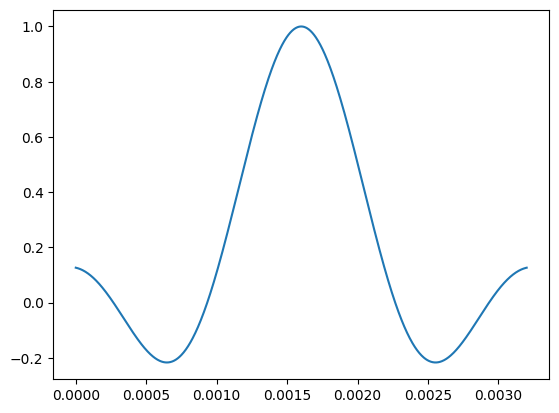


B1 Amplitude: 4.561047493220179e-06 T or 4.561047493220179 uT



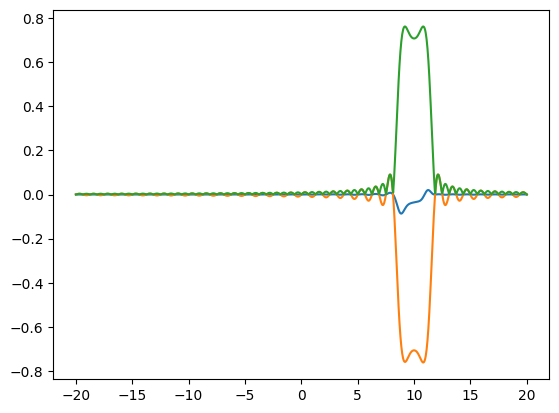

In [14]:
def bloch_sim_rf(b1_t, t, G_t, z_axis_m):
    
    # Time steps
    dt = np.diff(t)

    M = np.zeros((3,z_axis_m.size))
    M[2,:] = 1.0 
    rephase = 0.0
    for k in range(len(dt)):
        alpha_x = gamma_rad_per_t * np.real(b1_t[k]) * dt[k]
        alpha_y = gamma_rad_per_t * np.imag(b1_t[k]) * dt[k]
        Rx = rotation_matrix_x(alpha_x) 
        Ry = rotation_matrix_y(alpha_y) 
        M = (Ry @ Rx) @ M 
        z_phase = gamma_rad_per_t * G_t[k] * z_axis_m * dt[k]
        mxy = (M[0,:] + 1j*M[1,:]) * np.exp(1j * z_phase)
        M[0,:] = np.real(mxy) 
        M[1,:] = np.imag(mxy)
        if k >= len(dt)//2:
            rephase += z_phase 
    mxy = (M[0,:] + 1j*M[1,:]) * np.exp(-1j * rephase) # slice rewinder 
    M[0,:] = np.real(mxy) 
    M[1,:] = np.imag(mxy)
    return M.T

# 1. 
bw = 1500.0
thick = 0.003 
G = bw / (gamma_hz_per_t * thick)
print(f'\nGradient Strength: {G} T/m or {G*1e3} mT/m\n')

# 2. 
T = 0.0032 
bw = 1500.0
t = np.linspace(0, T, 1000) 
b1_t = np.sinc( bw * (t - T/2))

plt.figure()
plt.plot(t, b1_t)
plt.show()

# 3. 
alpha = 45 * np.pi / 180 
dt = t[1] - t[0]
alpha_pre = gamma_rad_per_t * np.sum(b1_t * dt)
b1_amplitude = alpha / alpha_pre 
b1_t = b1_t * b1_amplitude
print(f'\nB1 Amplitude: {b1_amplitude} T or {1e6 * b1_amplitude} uT\n')


# 4. 
shift = 0.01 
ph = np.exp(1j * gamma_rad_per_t * G * shift * t)
b1_t = b1_t * ph 

# 5. 
G_t = np.ones_like(t) * G 
z = np.linspace(-0.02, 0.02, 1000)
M = bloch_sim_rf(b1_t, t, G_t, z)
mxy = M[:,0] + 1j * M[:,1]

plt.figure()
plt.plot(1e3*z,np.real(mxy))
plt.plot(1e3*z,np.imag(mxy))
plt.plot(1e3*z,np.abs(mxy))
plt.show()
